# MTH739 – Topics in Scientific Computing 2025/26
# Coursework 1 : Trisolaris: the three body problem

### Setup

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

G = 1.0   # We work in units where G = 1 as instructed


# SIMPLE STAR CLASS

class Star:
    
    # Represents a star with mass m, position x,y and velocity vx, vy

    def __init__(self, mass, x, y, vx, vy):
        self.mass = mass
        self.x = x
        self.y = y
        self.vx = vx
        self.vy = vy


# STAR SYSTEM CLASS

class StarSystem:
    
    # Represents a system of stars

    def __init__(self, stars):
        self.stars = stars


    # Calculate accelerations

    def compute_accelerations(self):
        
    # Returns arrays ax, ay of accelerations for each star due to all others

        N = len(self.stars)
        ax = np.zeros(N)
        ay = np.zeros(N)

        for i in range(N):
            for j in range(N):
                if i == j:
                    continue
                xi, yi = self.stars[i].x, self.stars[i].y
                xj, yj = self.stars[j].x, self.stars[j].y

                dx = xj - xi
                dy = yj - yi
                r = np.sqrt(dx*dx + dy*dy)

                ax[i] += self.stars[j].mass * dx / r**3
                ay[i] += self.stars[j].mass * dy / r**3

        return ax, ay


    # RHS FOR solve_ivp

    def ode_rhs(self, t, y):
        """
        y = [x1,y1,vx1,vy1, x2,y2,vx2,vy2, ...]
        Returns dy/dt in same order.
        """
        N = len(self.stars)
        # Extract updated values from y
        for i in range(N):
            self.stars[i].x  = y[4*i]
            self.stars[i].y  = y[4*i+1]
            self.stars[i].vx = y[4*i+2]
            self.stars[i].vy = y[4*i+3]

        ax, ay = self.compute_accelerations()

        dydt = []
        for i in range(N):
            dydt += [
                self.stars[i].vx,   # dx/dt
                self.stars[i].vy,   # dy/dt
                ax[i],              # dvx/dt
                ay[i]               # dvy/dt
            ]
        return dydt


## Problem 1: Binary System

The masses are 𝑀1 = 0.6 and 𝑀2 = 0.3\

Star 1 starts with velocity (0,−0.1)

To keep the centre of mass fixed (zero momentum), Star 2 must satisfy: M1 ​v1y ​+ M2 ​v2y ​= 0

Solving this gives:


In [8]:
# Define the two stars
M1, M2 = 0.6, 0.3

# Star 1 initial conditions
x1, y1 =  2.0, 0.0
vx1, vy1 = 0.0, -0.1

# Compute Star 2 velocity for zero total momentum
vy2 = -(M1 * vy1) / M2   # = 0.2

x2, y2 = -2.0, 0.0
vx2 = 0.0

star1 = Star(M1, x1, y1, vx1, vy1)
star2 = Star(M2, x2, y2, vx2, vy2)

binary = StarSystem([star1, star2])

# Initial state vector
y0 = [
    star1.x, star1.y, star1.vx, star1.vy,
    star2.x, star2.y, star2.vx, star2.vy
]

# Time span for integration
t_span = (0, 200)
t_eval = np.linspace(0, 200, 5000)

sol = solve_ivp(binary.ode_rhs, t_span, y0, t_eval=t_eval, rtol=1e-9, atol=1e-12)


#### Trajectories

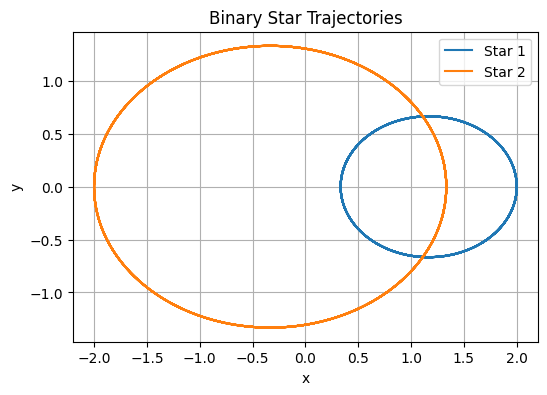

In [9]:
x1_vals = sol.y[0]
y1_vals = sol.y[1]
x2_vals = sol.y[4]
y2_vals = sol.y[5]

plt.figure(figsize=(6,6))
plt.plot(x1_vals, y1_vals, label="Star 1")
plt.plot(x2_vals, y2_vals, label="Star 2")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Binary Star Trajectories")
plt.gca().set_aspect('equal', 'box')
plt.grid(True)
plt.show()


#### Phase Diagram

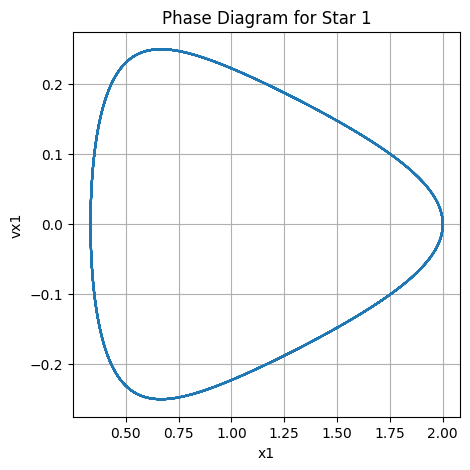

In [10]:
plt.figure(figsize=(5,5))
plt.plot(x1_vals, sol.y[2])  # x vs vx
plt.xlabel("x1")
plt.ylabel("vx1")
plt.title("Phase Diagram for Star 1")
plt.grid(True)
plt.show()


    The phase diagram of 𝑥1 vs vx1 shows:

    The motion of the star is periodic and stable. 

    The orbit repeats over time and that the system remains bounded.

#### Implementing the midpoint method

In [12]:
def midpoint_method(system, y0, t_end, dt):
    t_vals = [0]
    y_vals = [np.array(y0, dtype=float)]
    y = np.array(y0, dtype=float)
    t = 0

    while t < t_end:
        k1 = np.array(system.ode_rhs(t, y))
        k2 = np.array(system.ode_rhs(t + dt/2, y + dt*k1/2))
        y = y + dt * k2
        t += dt
        t_vals.append(t)
        y_vals.append(y.copy())

    return np.array(t_vals), np.array(y_vals).T


#### Converg

In [13]:
def endpoint_x2(dt):
    t_vals, y_vals = midpoint_method(binary, y0, 50, dt)
    return y_vals[4, -1]   # x2 at final time

err_dt  = abs(endpoint_x2(0.02) - endpoint_x2(0.01))
err_dt2 = abs(endpoint_x2(0.01) - endpoint_x2(0.005))

print("Error ratio =", err_dt / err_dt2)


Error ratio = 1.6123274817349975
